# Блок заданий 07: автоматическое дифференцирование

## Вспомогательный код

*(Можно не смотреть, но надо запустить)*

In [46]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
from abc import ABC, abstractmethod

In [47]:
ok = set()  # это служебная структура, чтобы Вам было проще смотреть все ли задания выполнены
all_tasks = (
    {f'1.{i}' for i in range(6)} |
    {'2.1', '3.1', '3.2'}
)

## Задания

### 1. Вспомогательные функции



#### 1.0. Тензор


Мы будем следовать названиям *PyTorch*, поэтому многомерный массив будем называть `Tensor`.

**Задача:** реализуйте класс `Tensor`, оборачивающий массив `np.ndarray`.


Реализация класса `Tensor` (**ваш код**):

In [48]:
class Tensor:
    def __init__(self, data: np.ndarray, requires_grad: bool = False):
        assert isinstance(data, np.ndarray)
        self.requires_grad = requires_grad
        self.data = data
        self.grad = None
        
    def numpy(self):
        return self.data

# вспомогательная функция, создающая `Tensor`
def tensor(data: np.ndarray | list, requires_grad: bool = True):
    if isinstance(data, np.ndarray):
        return Tensor(data, requires_grad=requires_grad)
    return Tensor(np.array(data), requires_grad=requires_grad)


Проверяем, что `Tensor` можно создавать, из него можно доставать данные методом `numpy()`:

In [49]:
a = Tensor(np.array([1., 123.]))
np.allclose(a.numpy(), [1., 123.])

True

Проверки, что задание выполнено верно:

In [50]:
data = np.array([1., 123.])
a = Tensor(data)
assert callable(getattr(a, 'numpy')), 'Должен быть метод .numpy()'
assert data is a.numpy(), 'Должны возвращаться в точности те же данные, что положили в тензор'

ok.add('1.0')

#### 1.1. Простейшие функции


**Задача:** следуя интерфейсу `AutogradFn`, реализуйте функции сложения и вычитания.


Интерфейс (нельзя менять):

In [51]:
class SimpleContext:
    def save_for_backward(self, *tensors):
        self.saved_tensors = tensors


class AutogradFn(ABC):
    @staticmethod
    @abstractmethod
    def forward(ctx, *args: Tensor):
        """
        Args:
            ctx: Context, you can save temporary data to it by calling `save_for_backward(...)`.
            *args: Input function arguments.

        Returns:
            Function value.
        """
        pass

    @staticmethod
    @abstractmethod
    def backward(ctx, *grads: Tensor):
        """
        Args:
            ctx: Context, you can load temporary data from it by field `.saved_tensors`.
            *grads: Gradients for each function output.

        Returns:
            Gradients for each function input.
        """
        pass


Реализация функции сложения:

In [52]:
class AddFn(AutogradFn):
    @staticmethod
    def forward(ctx, a, b):  # должен возвращать `Tensor`
        return Tensor(a.numpy() + b.numpy())

    @staticmethod
    def backward(ctx, grads):
        g = grads.numpy()
        return Tensor(g), Tensor(g)


In [53]:
ctx = SimpleContext()
a, b = Tensor(np.array([1., 2.])), Tensor(np.array([3., 4.]))
print(AddFn.forward(ctx, a, b).numpy())

grad_a, grad_b = AddFn.backward(ctx, Tensor(np.array([1., 1.])))
print(grad_a.numpy(), grad_b.numpy())

[4. 6.]
[1. 1.] [1. 1.]


Реализация функции вычитания:

In [54]:
class SubFn(AutogradFn):
    @staticmethod
    def forward(ctx, a, b):
        return Tensor(a.numpy() - b.numpy())

    @staticmethod
    def backward(ctx, grads):
        g = grads.numpy()
        return Tensor(g), Tensor(-g)


In [55]:
ctx = SimpleContext()
a, b = Tensor(np.array([1., 2.])), Tensor(np.array([3., 4.]))
print(SubFn.forward(ctx, a, b).numpy())

grad_a, grad_b = SubFn.backward(ctx, Tensor(np.array([1., 1.])))
print(grad_a.numpy(), grad_b.numpy())

[-2. -2.]
[1. 1.] [-1. -1.]


Проверки, что задание выполнено верно:

In [56]:
ctx_add = SimpleContext()
a, b = Tensor(np.array([1., 2.])), Tensor(np.array([3., 4.]))
assert np.allclose(AddFn.forward(ctx_add, a, b).numpy(), [4., 6.]), 'Неправильное сложение'

grad_a, grad_b = AddFn.backward(ctx_add, Tensor(np.array([1., 1.])))
assert np.allclose(grad_a.numpy(), grad_b.numpy()), 'Неправильные производные сложения'

ctx_sub = SimpleContext()
a, b = Tensor(np.array([1., 2.])), Tensor(np.array([3., 4.]))
assert np.allclose(SubFn.forward(ctx_sub, a, b).numpy(), [-2., -2.]), 'Неправильное вычитание'

grad_a, grad_b = SubFn.backward(ctx_sub, Tensor(np.array([1., 1.])))
assert np.allclose(grad_a.numpy(), [1., 1.]), 'Неправильные производные вычитания'
assert np.allclose(grad_b.numpy(), [-1., -1.]), 'Неправильные производные вычитания'

ok.add('1.1')

#### 1.2. Чуть более сложные функции: умножение матриц


**Задача:** следуя интерфейсу `AutogradFn`, реализуйте функцию умножения матриц.


Реализация функции умножения матриц:

In [57]:
class MatMulFn(AutogradFn):
    @staticmethod
    def forward(ctx, a, b):
        ctx.save_for_backward(a, b)
        return Tensor(a.numpy() @ b.numpy())

    @staticmethod
    def backward(ctx, grads):
        a, b = ctx.saved_tensors
        g = grads.numpy()
        grad_a = g @ b.numpy().T
        grad_b = a.numpy().T @ g
        return Tensor(grad_a), Tensor(grad_b)


In [58]:
ctx = SimpleContext()
a = Tensor(np.array([
    [1., 2.],
    [3., 4.],
]))
b = Tensor(np.array([[5.], [6.]]))
print(MatMulFn.forward(ctx, a, b).numpy())

grad_a, grad_b = MatMulFn.backward(ctx, Tensor(np.array([[1.], [1.]])))
print(grad_a.numpy(), grad_b.numpy())

[[17.]
 [39.]]
[[5. 6.]
 [5. 6.]] [[4.]
 [6.]]


Проверки, что задание выполнено верно:

In [59]:
ctx_mul = SimpleContext()
a = Tensor(np.array([
    [1., 2.],
    [3., 4.],
]))
b = Tensor(np.array([[5.], [6.]]))
res = MatMulFn.forward(ctx_mul, a, b)
assert np.allclose(res.numpy(), a.numpy() @ b.numpy()), 'Неправильное произведение матрицы на вектор'

grad_a, grad_b = MatMulFn.backward(ctx_mul, Tensor(np.array([[1.], [1.]])))
assert grad_a.numpy().shape == a.numpy().shape, 'Неправильные размерности производных по `a`'
assert grad_b.numpy().shape == b.numpy().shape, 'Неправильные размерности производных по `b`'
assert np.allclose(grad_a.numpy(), np.array([[5., 6.], [5., 6.]])), 'Неправильные производные по `a`'
assert np.allclose(grad_b.numpy(), np.array([[4.], [6.]])), 'Неправильные производные по `b`'

ok.add('1.2')

#### 1.3. Чуть более сложные функции: сумма


**Задача:** следуя интерфейсу `AutogradFn`, реализуйте функцию суммы элементов матрицы.

*Обратите внимание, число-результат можно положить в `numpy.array(...)`, чтобы не нарушать совместимость с интерфейсом.*

Реализация функции суммы:

In [60]:
class SumFn(AutogradFn):
    @staticmethod
    def forward(ctx, a):
        ctx.save_for_backward(a)
        return Tensor(np.array(np.sum(a.numpy())))

    @staticmethod
    def backward(ctx, grads):
        a, = ctx.saved_tensors
        shape = a.numpy().shape
        g = float(np.asarray(grads.numpy()))
        return Tensor(np.full(shape, g))


In [61]:
ctx = SimpleContext()
a = Tensor(np.array([
    [1., 2.],
    [3., 4.],
]))
print(SumFn.forward(ctx, a).numpy())

grad_a = SumFn.backward(ctx, Tensor(np.array(1.0)))
print(grad_a.numpy())

10.0
[[1. 1.]
 [1. 1.]]


Проверки, что задание выполнено верно:

In [62]:
ctx_sum = SimpleContext()
a = Tensor(np.array([
    [1., 2.],
    [3., 4.],
]))
s = SumFn.forward(ctx_sum, a)
grad_a = SumFn.backward(ctx_sum, Tensor(np.array(1.0)))

assert s.numpy() == 10.0, 'Сумма элементов должна быть равна 10'
assert np.allclose(grad_a.numpy(), np.full((2, 2), 1.)), 'Производные должны быть равны 1'

ok.add('1.3')

#### 1.4. Чуть более сложные функции: поэлементное позведение в степень


**Задача:** следуя интерфейсу `AutogradFn`, реализуйте функцию поэлементного возведения в степень $2$.


Реализация функции возведения в степень:

In [63]:
class Pow2Fn(AutogradFn):
    @staticmethod
    def forward(ctx, a):
        ctx.save_for_backward(a)
        return Tensor(a.numpy() ** 2)

    @staticmethod
    def backward(ctx, grads):
        a, = ctx.saved_tensors
        return Tensor(2.0 * a.numpy() * grads.numpy())


In [64]:
ctx = SimpleContext()
a = Tensor(np.array([
    [1., 2.],
    [3., 4.],
]))
print(Pow2Fn.forward(ctx, a).numpy())

grad_a = Pow2Fn.backward(ctx, Tensor(np.array([[1.0, 1.0], [1.0, 1.0]])))
print(grad_a.numpy())

[[ 1.  4.]
 [ 9. 16.]]
[[2. 4.]
 [6. 8.]]


Проверки, что задание выполнено верно:

In [65]:
ctx_pow2 = SimpleContext()
a = Tensor(np.array([
    [1., 2.],
    [3., 4.],
]))
s = Pow2Fn.forward(ctx_pow2, a)
grad_a = Pow2Fn.backward(ctx_pow2, Tensor(np.full((2, 2), 1.0)))

assert np.allclose(s.numpy(), np.array([[1., 4.], [9., 16.]])), 'Элементы должны возводиться в квадрат'
assert np.allclose(grad_a.numpy(), np.array([[2., 4.], [6., 8.]])), 'Неверные производные'

ok.add('1.4')

#### 1.5. ★ Чуть более сложные функции: reshape


**Задача:** следуя интерфейсу `AutogradFn`, реализуйте функцию reshape.


Реализация функции reshape:

In [66]:
class ReshapeFn(AutogradFn):
    @staticmethod
    def forward(ctx, a, shape=None):  # обратите внимание, здесь shape – не тензор, поэтому мы сделали его ключевым аргументом
        ctx.save_for_backward(a)
        return Tensor(np.reshape(a.numpy(), shape))

    @staticmethod
    def backward(ctx, grads):
        a, = ctx.saved_tensors
        return Tensor(np.reshape(grads.numpy(), a.numpy().shape))


In [67]:
ctx = SimpleContext()
a = Tensor(np.array([
    [1., 2., 3.],
    [4., 5., 6.],
]))
print(ReshapeFn.forward(ctx, a, shape=(3, 2)).numpy())

grad_a = ReshapeFn.backward(ctx, Tensor(np.ones((3, 2))))
print(grad_a.numpy())

[[1. 2.]
 [3. 4.]
 [5. 6.]]
[[1. 1. 1.]
 [1. 1. 1.]]


Проверки, что задание выполнено верно:

In [68]:
ctx_reshape = SimpleContext()
a = Tensor(np.array([
    [1., 2., 3.],
    [4., 5., 6.],
]))
s = ReshapeFn.forward(ctx_reshape, a, shape=(3, 2))
grad_a = ReshapeFn.backward(ctx_reshape, Tensor(np.ones((3, 2))))

assert s.numpy().shape == (3, 2), 'Должны получиться размерности (3, 2)'
assert grad_a.numpy().shape == (2, 3), 'Размерности производных должны совпадать с размерностями `a`'

ok.add('1.5')

### 2. Реализация обратного автоматического дифференцирования

#### 2.1. Простейший рекурсивный вариант

**Задача:** реализуйте функцию `calc_v1`, принимающую на вход операцию и тензоры-аргументы, возвращающую тензор с результатом и полями, необходимыми для обратного прохода.

Также реализуйте функцию `backward_v1`, принимающую последний тензор на вход, и соверщающую обратный проход с вызовом всех `backward` функций у операций.

В результате у каждого тезнора, участвовавшего в вычислениях с `requires_grad=True` должно заполняться поле `grad`, в котором должны быть сохранены производные (а именно, производные того узла, в котором была вызвана функция `backward_v1`, по переменным данного узла).

Для простоты в этом задании подразумевается, что все функции возвращали ровно одно значение (соответственно, и входной аргумент `grads` в `backward(ctx, grads)` всего один).


**Ваша реализация:**

In [69]:
def calc_v1(autograd_fn: AutogradFn, *args: Tensor, **kwargs):
    ctx = SimpleContext()
    out_tensor = autograd_fn.forward(ctx, *args, **kwargs)
    need_grad = any(getattr(a, 'requires_grad', False) for a in args)
    result = Tensor(out_tensor.numpy(), requires_grad=need_grad)
    if need_grad:
        result.autograd_fn = autograd_fn
        result.ctx = ctx
        result.parents = list(args)
    return result


def backward_v1(current: Tensor, input_grads: Tensor | None = None):
    if not current.requires_grad:
        return
    if input_grads is None:
        input_grads = Tensor(np.full_like(current.numpy(), 1.0))  # на вход подаются значения 1.0
    
    parents = getattr(current, 'parents', None)
    if parents is None:
        if current.grad is None:
            current.grad = Tensor(np.zeros_like(current.numpy()))
        current.grad = Tensor(current.grad.numpy() + input_grads.numpy())
        return
    outs = current.autograd_fn.backward(current.ctx, input_grads)
    if not isinstance(outs, tuple):
        outs = (outs,)
    for p, g in zip(parents, outs):
        backward_v1(p, g)
    
    # учтите, что некоторые функции (вроде `SumFn`) принимают на вход один аргумент, а значит возвращают не tuple,
    # а один тензор


1. Создаём простой граф вычислений и проверяем производные:

In [70]:
a1 = tensor([1., 2.], requires_grad=True)
b1 = tensor([3., 4.], requires_grad=True)
c1 = tensor([5., 6.], requires_grad=True)

# d1 = (a1 - (b1 + c1))
d1 = calc_v1(SubFn, a1, calc_v1(AddFn, b1, c1))
e1 = calc_v1(SumFn, d1)
backward_v1(e1)

In [71]:
d1.numpy()

array([-7., -8.])

In [72]:
a1.grad.numpy(), b1.grad.numpy(), c1.grad.numpy()

(array([1., 1.]), array([-1., -1.]), array([-1., -1.]))

2. Чуть более сложный граф вычислений:

In [73]:
x = tensor([
    [1., 0.],
    [2., 0.],
    [3., 1.],
])
w = tensor([[7.], [8.]], requires_grad=True)
b = tensor([[1.], [1.], [1.]], requires_grad=True)
y = tensor([[10.], [20.], [10.]])

# pred = (b + x @ w)
# e = (pred - y).pow2().sum()
pred = calc_v1(AddFn, b, calc_v1(MatMulFn, x, w))
e = calc_v1(SumFn, calc_v1(Pow2Fn, calc_v1(SubFn, pred, y)))
backward_v1(e)

In [74]:
e.numpy()

array(429.)

In [75]:
w.grad.numpy(), b.grad.numpy()

(array([[96.],
        [40.]]),
 array([[ -4.],
        [-10.],
        [ 40.]]))

In [76]:
assert np.allclose(a1.grad.numpy(), [1., 1.])
assert np.allclose(b1.grad.numpy(), [-1., -1.])
assert np.allclose(c1.grad.numpy(), [-1., -1.])

assert np.allclose(w.grad.numpy(), [[96.], [40]])
assert np.allclose(b.grad.numpy(), [[-4.], [-10.], [40.]])


ok.add('2.1')

### 3. Применение обратного автоматического дифференцирования

#### 3.1. Реализация линейной регрессии

**Задача:** реализуйте линейную регрессию, используя ваш движок автоматического дифференцирования.


Сделаем более удобную обёртку для тензоров, вызывающую наши методы (этот код для краткости, его можно не менять или не использовать):

In [77]:
class T:
    def __init__(self, data, requires_grad=False):
        if isinstance(data, Tensor):
            self.tensor = data
        else:
            self.tensor = tensor(data, requires_grad=requires_grad)
        self._calc_fn = calc_v1
        self._backward_fn = backward_v1

    def numpy(self):
        return self.tensor.numpy()

    def __matmul__(self, other):
        return T(self._calc_fn(MatMulFn, self.tensor, other.tensor))

    def __add__(self, other):
        return T(self._calc_fn(AddFn, self.tensor, other.tensor))

    def __sub__(self, other):
        return T(self._calc_fn(SubFn, self.tensor, other.tensor))

    def sum(self):
        return T(self._calc_fn(SumFn, self.tensor))
    
    def pow2(self):
        return T(self._calc_fn(Pow2Fn, self.tensor))

    def backward(self, input_grads=None):
        return self._backward_fn(self.tensor, input_grads)


**Данные и начальное приближение параметров:**

In [78]:
x = T([
    [1., 0.],
    [2., 0.],
    [3., 1.],
])
y = T([[10.], [20.], [10.]])

w = T([[7.], [8.]], requires_grad=True)
b = T([1.], requires_grad=True)

**Ваша реализация:**

In [79]:
x = T([
    [1., 0.],
    [2., 0.],
    [3., 1.],
])
y = T([[10.], [20.], [10.]])
w = T([[7.], [8.]], requires_grad=True)
b = T([1.], requires_grad=True)

lr = 1.e-2
history = []

for i in range(5000):
    pred = x @ w + b
    e = (pred - y).pow2().sum()  # квадратичная ошибка
    w.tensor.grad = None
    b.tensor.grad = None
    e.backward()

    gw = w.tensor.grad.numpy()
    gb = b.tensor.grad.numpy()
    while gw.ndim > w.tensor.numpy().ndim:
        gw = gw.sum(axis=0)
    while gb.ndim > b.tensor.numpy().ndim:
        gb = gb.sum(axis=0)
    w.tensor.numpy()[:] -= lr * gw.reshape(w.tensor.numpy().shape)
    b.tensor.numpy()[:] -= lr * gb.reshape(b.tensor.numpy().shape)
    
    history.append(e.numpy().item())

График "обучения":

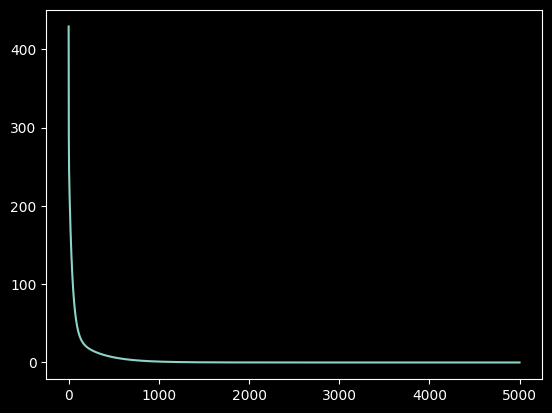

In [80]:
plt.plot(history)

In [81]:
w.numpy(), b.numpy()

(array([[  9.99865578],
        [-19.99778022]]),
 array([0.00200702]))

In [82]:
np.abs(x.numpy() @ w.numpy() + b.numpy() - y.numpy()).max()

np.float64(0.000681412963771777)

In [83]:
assert np.abs(x.numpy() @ w.numpy() + b.numpy() - y.numpy()).max() < 1.e-2, 'Ошибка на обучающем множестве должна быть небольшой'

ok.add('3.1')

#### 3.2. Реализация линейной регрессии на PyTorch

**Задача:** реализуйте линейную регрессию, используя PyTorch.


In [84]:
import torch

**Данные и начальное приближение параметров:**

In [85]:
x = torch.tensor([
    [1., 0.],
    [2., 0.],
    [3., 1.],
])
y = torch.tensor([[10.], [20.], [10.]])


w = torch.tensor([[7.], [8.]], requires_grad=True)
b = torch.tensor([1.], requires_grad=True)

**Ваша реализация:**

In [86]:
import torch

x = torch.tensor([
    [1., 0.],
    [2., 0.],
    [3., 1.],
])
y = torch.tensor([[10.], [20.], [10.]])
w = torch.tensor([[7.], [8.]], requires_grad=True)
b = torch.tensor([1.], requires_grad=True)

lr = 1.e-2
history = []
for i in range(5000):
    pred = x @ w + b
    e = (pred - y).pow(2).sum()
    e.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    if w.grad is not None:
        w.grad.zero_()
    if b.grad is not None:
        b.grad.zero_()
    
    history.append(e.item())

График "обучения":

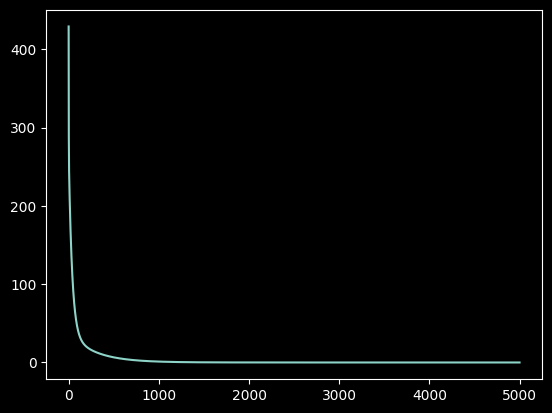

In [87]:
plt.plot(history)

In [88]:
w.detach().numpy(), b.detach().numpy()

(array([[  9.998625],
        [-19.997704]], dtype=float32),
 array([0.00204074], dtype=float32))

In [89]:
np.abs(x.numpy() @ w.detach().numpy() + b.detach().numpy() - y.numpy()).max()

np.float32(0.0007095337)

In [90]:
with torch.no_grad():
    assert np.abs(x.numpy() @ w.numpy() + b.numpy() - y.numpy()).max() < 1.e-2, 'Ошибка на обучающем множестве должна быть небольшой'

ok.add('3.2')

## Итоги

In [91]:
print(f'Выполнены задания: {sorted(ok)}')
print(f'Осталось: {all_tasks - ok}')
print(f'Выполнено: {len(ok)}. Не выполнено: {len(all_tasks - ok)}')

Выполнены задания: ['1.0', '1.1', '1.2', '1.3', '1.4', '1.5', '2.1', '3.1', '3.2']
Осталось: set()
Выполнено: 9. Не выполнено: 0
